In [1]:
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
pd.set_option('display.max_columns', 100)

# ✅ Load merged_df.csv
dfx = pd.read_csv("/Users/anandguntuku/Movies/VSCodeFolder/SarvaniMLOps/Data/merged_df.csv", parse_dates=["Date_Time"])
dfx.head(3)

/var/folders/_n/g_d34gh57sb9jndsrxxvvdy40000gn/T/ipykernel_2066/1057284260.py:7: DtypeWarning: Columns (28) have mixed types. Specify dtype option on import or set low_memory=False.
  dfx = pd.read_csv("/Users/anandguntuku/Movies/VSCodeFolder/SarvaniMLOps/Data/merged_df.csv", parse_dates=["Date_Time"])


,Outlet,Date_Time,Bill_No,Item_Price,Item_Quantity,Item_Total_Amount,Bill_Item_Count,Order_Type,Weekday,Total_Bill_Amount_Corrected,Daily_Bill_Amount,Corrected_Item_Name,Portion_Code,Corrected_Item_Category,total_weight_kg,Festivity_x,Bill_Class,Date,Unnamed: 0,Year,Month,Week_Number,Day,Festivity_y,Quarter,Festivity_Group,Day_Type,DayFestGroup,Holiday_Name
0,MADDILAPALEM OUTLET,2022-04-01 06:54:17.779,2022211,266.6667,1.0,279.9967,1,general,4,280.0,209884.0,KOVABISCUITS(ORANGE)0500G,0500G,KOVA SWEETS0500G,0.5,regular,Small,2022-04-01,33,2022,4,13,1,regular,Q1,Non-Festive,Wknd,Wknd - Non-Festive,NaN
1,MADDILAPALEM OUTLET,2022-04-01 08:27:52.593,2022212,180.9524,1.0,190.0024,1,general,4,190.0,209884.0,MOTHICHOORLADDURED0500G,0500G,LADDUS0500G,0.5,regular,Micro,2022-04-01,34,2022,4,13,1,regular,Q1,Non-Festive,Wknd,Wknd - Non-Festive,NaN
2,MADDILAPALEM OUTLET,2022-04-01 08:56:43.153,2022213,128.5714,2.0,270.0029,2,general,4,385.0,209884.0,BELLAMPUTHAREKULU0250G,0250G,HOME FOODS0250G,0.5,regular,Small,2022-04-01,35,2022,4,13,1,regular,Q1,Non-Festive,Wknd,Wknd - Non-Festive,NaN


In [32]:
class SegmentationAnalyzer:

    def __init__(self):
        self.color_map = {
            'Wkdy - Festive': "#FDEB4C",
            'Wknd - Festive': "#FFC506",
            'Wkdy - Non-Festive': '#D8BFD8',
            'Wknd - Non-Festive': "#F702F7"
        }
        self.desired_order = ['Micro', 'Small', 'Medium', 'Large', 'Heavy', 'Unknown']


## 🧠 A. **Customer Segmentation & Spend Behavior**
#🎯 Insight Objective: Understand footfall and spend patterns across weekdays vs weekends.
#> A.1. **P(Footfall | Day Type)**
#> *How does bill count with unique bill_no vary between weekdays and weekends?* 
    def analyze_a1(self, df):
        """A.1: Unique Bill Count (Footfall) by Day Type"""
        
        df = df.copy()
        df['Bill_Class'] = pd.Categorical(df['Bill_Class'], categories=self.desired_order, ordered=True)

        # Create festivity group
        df['Festivity_Group'] = df['Festivity_x'].apply(
            lambda x: 'Festive' if x == 'non-regular positive' else 'Non-Festive'
        )
        df['DayFestGroup'] = df['Day_Type'] + " - " + df['Festivity_Group']

        # Footfall chart
        footfall = df.groupby("Day_Type")["Bill_No"].nunique().reset_index()
        fig1 = px.bar(footfall, x="Day_Type", y="Bill_No", text_auto=True,
                      title="Volume of Bills (Footfall)")
        
        fig1.update_layout(yaxis_title="Unique Bill Count", xaxis_title="Day Type")
        fig1.show()

        # Unique bills only
        unique_bills = df.drop_duplicates(subset='Bill_No')

        grouped = unique_bills.groupby(['Day_Type', 'Festivity_Group']).agg({
            'Bill_No': 'nunique',
            'Total_Bill_Amount_Corrected': ['sum', 'mean']
        }).reset_index()

        grouped.columns = ['Day_Type', 'Festivity_Group', 'Bill_Count', 'Total_Bill_Amount_Corrected', 'Avg_Bill_Amount']

        total_sum = grouped['Total_Bill_Amount_Corrected'].sum()
        grouped['Percent_Share'] = (grouped['Total_Bill_Amount_Corrected'] / total_sum * 100).round(2)

        from IPython.display import display
        display(grouped.style.background_gradient(cmap="YlGnBu").format({
            "Percent_Share": "{:.2f}%", 
            "Avg_Bill_Amount": "₹{:.2f}"
        }))


#2. **P(Bill Class | Day Type)**
#> *What is the probability distribution of Micro, Small, Medium, Large, and Bulk bills on weekdays vs weekends?* Include Festive and Non-Festive days
    def analyze_a2(self,df):
        """A.2: P(Bill Class | Day Type) – Count Share"""
        
        count = df.groupby(["DayFestGroup", "Bill_Class"])["Bill_No"].nunique().reset_index()
        total = count.groupby("DayFestGroup")["Bill_No"].transform("sum")
        count["Percent_Share"] = (count["Bill_No"] / total * 100).round(0)

        #count['Bill_Class'] = pd.Categorical(count['Bill_Class'], categories=desired_order, ordered=True)
        #count = count.sort_values("Bill_Class")

        pivot = count.pivot(index="Bill_Class", columns="DayFestGroup", values="Percent_Share").fillna(0)
        pivot = pivot.loc[self.desired_order]
        display(pivot.style.background_gradient(cmap="YlGnBu").format("{:.2f}%"))
        
        # Step 4: Plot
        fig = px.bar(
            count,
            x="Bill_Class",
            y="Percent_Share",
            color="DayFestGroup",
            barmode="group",
            title="Distribution of Bill Classes across DayFestGroup",
            category_orders={"Bill_Class": self.desired_order}, 
                             color_discrete_map=self.color_map)
        fig.update_layout(yaxis_title="% Count Share", xaxis_title="Bill Class")
        fig.show()
    

#3. **P(Bill Class | Day Type)**
#> *What is the Bill Amount distribution of Micro, Small, Medium, Large, and Bulk bills on weekdays vs weekends?* Include Festive and Non-Festive days
    def analyze_a3(self,df):
        """A.3: P(Bill Class | Day Type) – Bill Amount Distribution"""
        amount = df.groupby(["DayFestGroup", "Bill_Class"])["Item_Total_Amount"].sum().reset_index()
        total = amount.groupby("DayFestGroup")["Item_Total_Amount"].transform("sum")
        amount["Percent_Share"] = (amount["Item_Total_Amount"] / total * 100).round(0)

        pivot = amount.pivot(index="Bill_Class", columns="DayFestGroup", values="Percent_Share").fillna(0)
        pivot = pivot.loc[self.desired_order]
        display(pivot.style.background_gradient(cmap="YlGnBu").format("{:.2f}%"))

        fig = px.bar(amount, x="Bill_Class", y="Percent_Share", color="DayFestGroup", barmode="group",
                     title="Total Amount Distribution by Bill Class and DayFestGroup",
                     category_orders={"Bill_Class": self.desired_order},
                     color_discrete_map=self.color_map)
        fig.update_layout(yaxis_title="% Bill Amount Share", xaxis_title="Bill Class")
        fig.show()


#4. **P(Bill Class | Day Type)**
#> *What is the TotalWeight(Kg) distribution of Micro, Small, Medium, Large, and Bulk bills on weekdays vs weekends?* Include Festive and Non-Festive days
    def analyze_a4(self,df):
        """A.4: P(Bill Class | Day Type) – Total Weight Distribution"""
        weight = df.groupby(["DayFestGroup", "Bill_Class"])["total_weight_kg"].sum().reset_index()
        total = weight.groupby("DayFestGroup")["total_weight_kg"].transform("sum")
        weight["Percent_Share"] = (weight["total_weight_kg"] / total * 100).round(0)

        pivot = weight.pivot(index="Bill_Class", columns="DayFestGroup", values="Percent_Share").fillna(0)
        pivot = pivot.loc[self.desired_order]
        display(pivot.style.background_gradient(cmap="YlGnBu").format("{:.2f}%"))

        fig = px.bar(weight, x="Bill_Class", y="Percent_Share", color="DayFestGroup", barmode="group",
                     title="Weight (kg) Distribution by Bill Class and DayFestGroup", 
                     category_orders={"Bill_Class": self.desired_order},
                     color_discrete_map=self.color_map)
        fig.update_layout(yaxis_title="%Total Weight Share", xaxis_title="Bill Class")
        fig.show()


#5. **P(Bill Class | Day Type)**
#> *What is the Stats of Bill Amount distribution of Micro, Small, Medium, Large, and Bulk bills on weekdays vs weekends?* Include Festive and Non-Festive days
    def analyze_a5(self, df):
        """A.5: Stats of Bill Amount by Bill Class and Day Type"""
        # Step 2: Drop duplicate bills
        df_unique = df.drop_duplicates(subset='Bill_No')

        # Step 3: Define function to compute required stats
        def describe_stats(x):
            return pd.Series({
                'Mean': round(x.mean(), 0),
                'Median': round(x.median(), 0),
                '25th Percentile': round(x.quantile(0.25), 0),
                '75th Percentile': round(x.quantile(0.75), 0)
            })

        # Step 4: Group by DayFestGroup and Bill_Class, apply stats on Bill_Amount
        summary_stats = df_unique.groupby(['Bill_Class', 'DayFestGroup'])['Total_Bill_Amount_Corrected'].apply(describe_stats).unstack()

        # Step 5: Reformat: one cell per Bill_Class x DayFestGroup with multiple lines
        formatted_table = summary_stats.groupby(level=0).apply(
            lambda group: group.apply(
                lambda row: f"Mean: ₹{row['Mean']}<br> Median: ₹{row['Median']}<br> P25: ₹{row['25th Percentile']}<br> P75: ₹{row['75th Percentile']}", 
                axis=1
            )
        ).unstack()

        return formatted_table.style.background_gradient(cmap="YlGnBu").format({"Percent_Share": "{:.2f}%", "Avg_Bill_Amount": "₹{:.2f}"})


#6. **P(Major Items & Categories | Day Type)**
#> Top 3 Items for Weekend and Weekday Festivity Group based on Bill_Amount
    def analyze_a6(self,df):
        """A.6: Top 3 Items by DayFestGroup"""
        # Step 1: Group again to get total bill amount per item
        grouped = df.groupby(['Bill_Class', 'DayFestGroup', 'Corrected_Item_Name', ])['Item_Total_Amount'].sum().reset_index()

        # Step 2: Compute total within each Bill_Class + DayFestGroup to calculate percentage
        grouped['Group_Total'] = grouped.groupby(['Bill_Class', 'DayFestGroup'])['Item_Total_Amount'].transform('sum')
        grouped['Percent_Contribution'] = ((grouped['Item_Total_Amount'] / grouped['Group_Total']) * 100).round(1)

        # Step 3: Extract top 3 items with their % contribution
        def top3_with_percent(sub_df):
            top_items = sub_df.sort_values('Item_Total_Amount', ascending=False).head(3)
            formatted = [
                f"{row['Corrected_Item_Name']} - {row['Percent_Contribution']}%<br>"
                for _, row in top_items.iterrows()
            ]
            return "\n\n".join(formatted)

        top3_percent_table = grouped.groupby(['Bill_Class', 'DayFestGroup']).apply(top3_with_percent).unstack(fill_value="")

        return top3_percent_table.style.background_gradient(cmap="YlGnBu").format({"Percent_Share": "{:.2f}%", "Avg_Bill_Amount": "₹{:.2f}"})


#7. **P(Item | Bill Class = Bill_class)**	Portion_Code	Corrected_Item_Category
#> *What items are most likely in very small bills/medium bills/large bills?*
    def analyze_a7(self,df, billclass):
        """A.7: Top Items for a Given Bill Class"""
        micro_df = df[df['Bill_Class'] == billclass]
        # Group by Item_Name and count
        item_counts = micro_df['Corrected_Item_Name'].value_counts().reset_index()
        item_counts.columns = ['Corrected_Item_Name', 'Count']

        # Compute total for normalization
        total_micro_bills = item_counts['Count'].sum()
        item_counts['Probability (%)'] = ((item_counts['Count'] / total_micro_bills).round(2)) * 100

        # Get total bill amount per item
        item_bill_amount = micro_df.groupby('Corrected_Item_Name')['Item_Total_Amount'].sum().reset_index(name='Item_Total_Amount')

        # Merge to item_counts
        item_counts = pd.merge(item_counts, item_bill_amount, on='Corrected_Item_Name')

        # Compute percentage contribution of bill amount
        total_amount = item_counts['Item_Total_Amount'].sum()
        item_counts['Item_Amount (%)'] = ((item_counts['Item_Total_Amount'] / total_amount).round(2)) * 100

        # Sort and filter
        item_counts = item_counts.sort_values(by='Probability (%)', ascending=False)
        item_counts_filtered = item_counts[item_counts['Item_Amount (%)'] >= 2]


        
        return item_counts_filtered.style.background_gradient(cmap="YlGnBu").format({"Percent_Share": "{:.2f}%", "Avg_Bill_Amount": "₹{:.2f}"})




In [3]:
analyzer = SegmentationAnalyzer()
df = dfx.copy()
df23 = dfx[dfx['Year']==2023]
df24 = dfx[dfx['Year']==2024]
df22 = dfx[dfx['Year']==2022]
df21 = dfx[dfx['Year']==2021]

## 🧠 A. **Customer Segmentation & Spend Behavior**
🎯 Insight Objective: Understand footfall and spend patterns across weekdays vs weekends.
> A.1. **P(Footfall | Day Type)**
> *How does bill count with unique bill_no vary between weekdays and weekends?* 

In [4]:
df.head(3)

,Outlet,Date_Time,Bill_No,Item_Price,Item_Quantity,Item_Total_Amount,Bill_Item_Count,Order_Type,Weekday,Total_Bill_Amount_Corrected,Daily_Bill_Amount,Corrected_Item_Name,Portion_Code,Corrected_Item_Category,total_weight_kg,Festivity_x,Bill_Class,Date,Unnamed: 0,Year,Month,Week_Number,Day,Festivity_y,Quarter,Festivity_Group,Day_Type,DayFestGroup,Holiday_Name
0,MADDILAPALEM OUTLET,2022-04-01 06:54:17.779,2022211,266.6667,1.0,279.9967,1,general,4,280.0,209884.0,KOVABISCUITS(ORANGE)0500G,0500G,KOVA SWEETS0500G,0.5,regular,Small,2022-04-01,33,2022,4,13,1,regular,Q1,Non-Festive,Wknd,Wknd - Non-Festive,NaN
1,MADDILAPALEM OUTLET,2022-04-01 08:27:52.593,2022212,180.9524,1.0,190.0024,1,general,4,190.0,209884.0,MOTHICHOORLADDURED0500G,0500G,LADDUS0500G,0.5,regular,Micro,2022-04-01,34,2022,4,13,1,regular,Q1,Non-Festive,Wknd,Wknd - Non-Festive,NaN
2,MADDILAPALEM OUTLET,2022-04-01 08:56:43.153,2022213,128.5714,2.0,270.0029,2,general,4,385.0,209884.0,BELLAMPUTHAREKULU0250G,0250G,HOME FOODS0250G,0.5,regular,Small,2022-04-01,35,2022,4,13,1,regular,Q1,Non-Festive,Wknd,Wknd - Non-Festive,NaN


  Day_Type  Total_Bill_Amount_Corrected  Percent_Share
0     Wkdy                  820620054.0           55.6
1     Wknd                  655314251.0           44.4


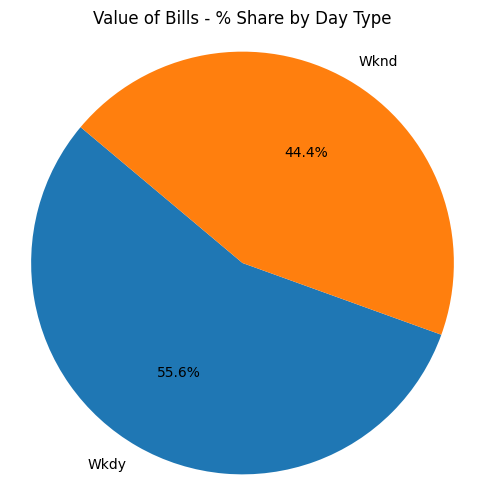

In [5]:
import matplotlib.pyplot as plt

dfy = df.drop_duplicates(subset = ['Outlet','Bill_No', 'Total_Bill_Amount_Corrected'])

# Assuming df is your DataFrame
unique_bills = dfy.drop_duplicates(subset='Bill_No')
# Sum of Bill_Amount for unique Bill_No by Day_Type
bill_amount_by_day = unique_bills.groupby('Day_Type')['Total_Bill_Amount_Corrected'].sum().reset_index()
# Step 2: Calculate % share
total_amount = unique_bills['Total_Bill_Amount_Corrected'].sum()
bill_amount_by_day['Percent_Share'] = (bill_amount_by_day['Total_Bill_Amount_Corrected'] / total_amount) * 100

# Optional: Round for clean display
bill_amount_by_day['Percent_Share'] = bill_amount_by_day['Percent_Share'].round(2)

print(bill_amount_by_day)
plt.figure(figsize=(6,6))
plt.pie(bill_amount_by_day['Percent_Share'],
        labels=bill_amount_by_day['Day_Type'],
        autopct='%1.1f%%',
        startangle=140)
plt.title('Value of Bills - % Share by Day Type')
plt.axis('equal')
plt.show()


In [6]:
# Run any analysis
analyzer.analyze_a1(df)

,Day_Type,Festivity_Group,Bill_Count,Total_Bill_Amount_Corrected,Avg_Bill_Amount,Percent_Share
0,Wkdy,Festive,156795,148139978.000000,₹944.80,10.04%
1,Wkdy,Non-Festive,1670448,672480076.000000,₹402.57,45.56%
2,Wknd,Festive,136829,105983650.000000,₹774.57,7.18%
3,Wknd,Non-Festive,1359302,549330601.000000,₹404.13,37.22%


In [7]:
df21 = dfx[dfx['Year']==2021]
analyzer = SegmentationAnalyzer()
# Initialize analyzer
analyzer.analyze_a1(df21)

,Day_Type,Festivity_Group,Bill_Count,Total_Bill_Amount_Corrected,Avg_Bill_Amount,Percent_Share
0,Wkdy,Festive,27834,27547237.000000,₹989.70,13.93%
1,Wkdy,Non-Festive,218774,83987674.000000,₹383.90,42.46%
2,Wknd,Festive,24596,14292385.000000,₹581.09,7.23%
3,Wknd,Non-Festive,187506,71982688.000000,₹383.90,36.39%


In [8]:
df22 = dfx[dfx['Year']==2022]
analyzer = SegmentationAnalyzer()
# Initialize analyzer
analyzer.analyze_a1(df22)

,Day_Type,Festivity_Group,Bill_Count,Total_Bill_Amount_Corrected,Avg_Bill_Amount,Percent_Share
0,Wkdy,Festive,44859,36034299.000000,₹803.28,8.53%
1,Wkdy,Non-Festive,477900,190798179.000000,₹399.24,45.18%
2,Wknd,Festive,42927,34246370.000000,₹797.78,8.11%
3,Wknd,Non-Festive,388635,161235967.000000,₹414.88,38.18%


In [9]:
df23 = dfx[dfx['Year']==2023]
analyzer = SegmentationAnalyzer()
# Initialize analyzer
analyzer.analyze_a1(df23)

,Day_Type,Festivity_Group,Bill_Count,Total_Bill_Amount_Corrected,Avg_Bill_Amount,Percent_Share
0,Wkdy,Festive,37935,38457077.000000,₹1013.76,8.85%
1,Wkdy,Non-Festive,505668,199476773.000000,₹394.48,45.91%
2,Wknd,Festive,45311,36448778.000000,₹804.41,8.39%
3,Wknd,Non-Festive,400536,160103501.000000,₹399.72,36.85%


In [10]:
df24 = dfx[dfx['Year']==2024]
analyzer = SegmentationAnalyzer()
# Initialize analyzer
analyzer.analyze_a1(df24)

,Day_Type,Festivity_Group,Bill_Count,Total_Bill_Amount_Corrected,Avg_Bill_Amount,Percent_Share
0,Wkdy,Festive,46167,46101365.000000,₹998.58,11.09%
1,Wkdy,Non-Festive,460201,192847807.000000,₹419.05,46.39%
2,Wknd,Festive,23995,20996117.000000,₹875.02,5.05%
3,Wknd,Non-Festive,382180,155752354.000000,₹407.54,37.47%


2. **P(Bill Class | Day Type)**
> *What is the probability distribution of Micro, Small, Medium, Large, and Bulk bills on weekdays vs weekends?* Include Festive and Non-Festive days


In [11]:
df.shape

(6407267, 29)

In [12]:
analyzer = SegmentationAnalyzer()
analyzer.analyze_a2(df)

DayFestGroup,Wkdy - Festive,Wkdy - Non-Festive,Wknd - Festive,Wknd - Non-Festive
Bill_Class,,,,
Micro,41.00%,53.00%,40.00%,51.00%
Small,36.00%,31.00%,37.00%,32.00%
Medium,17.00%,13.00%,17.00%,14.00%
Large,4.00%,2.00%,4.00%,2.00%
Heavy,2.00%,0.00%,2.00%,0.00%
Unknown,0.00%,0.00%,0.00%,0.00%


In [13]:
analyzer = SegmentationAnalyzer()
analyzer.analyze_a2(df24)

DayFestGroup,Wkdy - Festive,Wkdy - Non-Festive,Wknd - Festive,Wknd - Non-Festive
Bill_Class,,,,
Micro,38.00%,54.00%,40.00%,52.00%
Small,36.00%,30.00%,37.00%,31.00%
Medium,19.00%,13.00%,18.00%,14.00%
Large,5.00%,2.00%,4.00%,2.00%
Heavy,2.00%,0.00%,1.00%,0.00%
Unknown,0.00%,0.00%,0.00%,0.00%


3. **P(Bill Class | Day Type)**
> *What is the Bill Amount distribution of Micro, Small, Medium, Large, and Bulk bills on weekdays vs weekends?* Include Festive and Non-Festive days

In [14]:
analyzer = SegmentationAnalyzer()
analyzer.analyze_a3(df)


DayFestGroup,Wkdy - Festive,Wkdy - Non-Festive,Wknd - Festive,Wknd - Non-Festive
Bill_Class,,,,
Micro,5.00%,15.00%,6.00%,15.00%
Small,16.00%,32.00%,20.00%,33.00%
Medium,18.00%,31.00%,22.00%,32.00%
Large,12.00%,14.00%,13.00%,13.00%
Heavy,50.00%,9.00%,40.00%,7.00%
Unknown,0.00%,0.00%,0.00%,0.00%


In [15]:
analyzer = SegmentationAnalyzer()
analyzer.analyze_a3(df24)

DayFestGroup,Wkdy - Festive,Wkdy - Non-Festive,Wknd - Festive,Wknd - Non-Festive
Bill_Class,,,,
Micro,5.00%,15.00%,6.00%,15.00%
Small,15.00%,30.00%,18.00%,32.00%
Medium,19.00%,30.00%,20.00%,32.00%
Large,13.00%,14.00%,12.00%,14.00%
Heavy,48.00%,11.00%,45.00%,7.00%
Unknown,0.00%,0.00%,0.00%,0.00%


4. **P(Bill Class | Day Type)**
> *What is the TotalWeight(Kg) distribution of Micro, Small, Medium, Large, and Bulk bills on weekdays vs weekends?* Include Festive and Non-Festive days

In [16]:
analyzer = SegmentationAnalyzer()
analyzer.analyze_a4(df)

DayFestGroup,Wkdy - Festive,Wkdy - Non-Festive,Wknd - Festive,Wknd - Non-Festive
Bill_Class,,,,
Micro,5.00%,12.00%,6.00%,12.00%
Small,17.00%,35.00%,21.00%,36.00%
Medium,16.00%,31.00%,21.00%,32.00%
Large,11.00%,13.00%,11.00%,12.00%
Heavy,51.00%,9.00%,40.00%,8.00%
Unknown,0.00%,0.00%,0.00%,0.00%


5. **P(Bill Class | Day Type)**
> *What is the Stats of Bill Amount distribution of Micro, Small, Medium, Large, and Bulk bills on weekdays vs weekends?* Include Festive and Non-Festive days

In [17]:
analyzer = SegmentationAnalyzer()
analyzer.analyze_a5(df)

,DayFestGroup,Wkdy - Festive,Wkdy - Non-Festive,Wknd - Festive,Wknd - Non-Festive
Bill_Class,Bill_Class,,,,
Heavy,Heavy,Mean: ₹23468.0 Median: ₹8750.0 P25: ₹6926.0 P75: ₹14618.0,Mean: ₹11096.0 Median: ₹7681.0 P25: ₹6000.0 P75: ₹10000.0,Mean: ₹19283.0 Median: ₹8405.0 P25: ₹6800.0 P75: ₹11208.0,Mean: ₹10915.0 Median: ₹7806.0 P25: ₹6000.0 P75: ₹10360.0
Large,Large,Mean: ₹2620.0 Median: ₹2320.0 P25: ₹1920.0 P75: ₹3085.0,Mean: ₹2463.0 Median: ₹2200.0 P25: ₹1870.0 P75: ₹2820.0,Mean: ₹2575.0 Median: ₹2280.0 P25: ₹1910.0 P75: ₹3000.0,Mean: ₹2433.0 Median: ₹2165.0 P25: ₹1860.0 P75: ₹2780.0
Medium,Medium,Mean: ₹971.0 Median: ₹900.0 P25: ₹740.0 P75: ₹1140.0,Mean: ₹955.0 Median: ₹880.0 P25: ₹740.0 P75: ₹1110.0,Mean: ₹963.0 Median: ₹880.0 P25: ₹740.0 P75: ₹1130.0,Mean: ₹950.0 Median: ₹875.0 P25: ₹740.0 P75: ₹1100.0
Micro,Micro,Mean: ₹124.0 Median: ₹115.0 P25: ₹60.0 P75: ₹180.0,Mean: ₹113.0 Median: ₹100.0 P25: ₹55.0 P75: ₹165.0,Mean: ₹123.0 Median: ₹110.0 P25: ₹60.0 P75: ₹180.0,Mean: ₹115.0 Median: ₹105.0 P25: ₹55.0 P75: ₹170.0
Small,Small,Mean: ₹416.0 Median: ₹390.0 P25: ₹320.0 P75: ₹500.0,Mean: ₹413.0 Median: ₹390.0 P25: ₹320.0 P75: ₹500.0,Mean: ₹415.0 Median: ₹400.0 P25: ₹325.0 P75: ₹500.0,Mean: ₹413.0 Median: ₹390.0 P25: ₹320.0 P75: ₹500.0
Unknown,Unknown,Mean: ₹10.0 Median: ₹10.0 P25: ₹10.0 P75: ₹10.0,Mean: ₹10.0 Median: ₹10.0 P25: ₹10.0 P75: ₹10.0,Mean: ₹10.0 Median: ₹10.0 P25: ₹10.0 P75: ₹10.0,Mean: ₹8.0 Median: ₹10.0 P25: ₹10.0 P75: ₹10.0


In [18]:
analyzer.analyze_a5(df22)

,DayFestGroup,Wkdy - Festive,Wkdy - Non-Festive,Wknd - Festive,Wknd - Non-Festive
Bill_Class,Bill_Class,,,,
Heavy,Heavy,Mean: ₹16127.0 Median: ₹8110.0 P25: ₹6870.0 P75: ₹11677.0,Mean: ₹11246.0 Median: ₹7500.0 P25: ₹6000.0 P75: ₹10720.0,Mean: ₹17716.0 Median: ₹8060.0 P25: ₹6875.0 P75: ₹9800.0,Mean: ₹10864.0 Median: ₹7670.0 P25: ₹6000.0 P75: ₹11000.0
Large,Large,Mean: ₹2630.0 Median: ₹2280.0 P25: ₹1920.0 P75: ₹3162.0,Mean: ₹2452.0 Median: ₹2180.0 P25: ₹1860.0 P75: ₹2814.0,Mean: ₹2607.0 Median: ₹2320.0 P25: ₹1900.0 P75: ₹3041.0,Mean: ₹2431.0 Median: ₹2160.0 P25: ₹1850.0 P75: ₹2790.0
Medium,Medium,Mean: ₹960.0 Median: ₹885.0 P25: ₹740.0 P75: ₹1125.0,Mean: ₹950.0 Median: ₹870.0 P25: ₹740.0 P75: ₹1110.0,Mean: ₹968.0 Median: ₹885.0 P25: ₹740.0 P75: ₹1150.0,Mean: ₹945.0 Median: ₹870.0 P25: ₹740.0 P75: ₹1095.0
Micro,Micro,Mean: ₹120.0 Median: ₹105.0 P25: ₹50.0 P75: ₹175.0,Mean: ₹113.0 Median: ₹100.0 P25: ₹50.0 P75: ₹165.0,Mean: ₹114.0 Median: ₹100.0 P25: ₹50.0 P75: ₹170.0,Mean: ₹117.0 Median: ₹105.0 P25: ₹55.0 P75: ₹170.0
Small,Small,Mean: ₹413.0 Median: ₹372.0 P25: ₹330.0 P75: ₹490.0,Mean: ₹411.0 Median: ₹386.0 P25: ₹320.0 P75: ₹490.0,Mean: ₹416.0 Median: ₹400.0 P25: ₹330.0 P75: ₹490.0,Mean: ₹412.0 Median: ₹390.0 P25: ₹320.0 P75: ₹494.0
Unknown,Unknown,Mean: ₹10.0 Median: ₹10.0 P25: ₹10.0 P75: ₹10.0,Mean: ₹10.0 Median: ₹10.0 P25: ₹10.0 P75: ₹10.0,Mean: ₹10.0 Median: ₹10.0 P25: ₹10.0 P75: ₹10.0,Mean: ₹10.0 Median: ₹10.0 P25: ₹10.0 P75: ₹10.0


In [19]:
analyzer.analyze_a5(df23)

,DayFestGroup,Wkdy - Festive,Wkdy - Non-Festive,Wknd - Festive,Wknd - Non-Festive
Bill_Class,Bill_Class,,,,
Heavy,Heavy,Mean: ₹32310.0 Median: ₹9000.0 P25: ₹7000.0 P75: ₹10368.0,Mean: ₹10187.0 Median: ₹7666.0 P25: ₹6000.0 P75: ₹9940.0,Mean: ₹18744.0 Median: ₹8670.0 P25: ₹7000.0 P75: ₹11591.0,Mean: ₹11295.0 Median: ₹7688.0 P25: ₹6089.0 P75: ₹10000.0
Large,Large,Mean: ₹2601.0 Median: ₹2280.0 P25: ₹1882.0 P75: ₹3060.0,Mean: ₹2460.0 Median: ₹2200.0 P25: ₹1865.0 P75: ₹2820.0,Mean: ₹2551.0 Median: ₹2230.0 P25: ₹1900.0 P75: ₹2960.0,Mean: ₹2431.0 Median: ₹2160.0 P25: ₹1855.0 P75: ₹2765.0
Medium,Medium,Mean: ₹961.0 Median: ₹885.0 P25: ₹740.0 P75: ₹1122.0,Mean: ₹957.0 Median: ₹880.0 P25: ₹740.0 P75: ₹1110.0,Mean: ₹963.0 Median: ₹895.0 P25: ₹740.0 P75: ₹1120.0,Mean: ₹953.0 Median: ₹880.0 P25: ₹740.0 P75: ₹1105.0
Micro,Micro,Mean: ₹118.0 Median: ₹105.0 P25: ₹50.0 P75: ₹175.0,Mean: ₹108.0 Median: ₹95.0 P25: ₹50.0 P75: ₹160.0,Mean: ₹120.0 Median: ₹110.0 P25: ₹55.0 P75: ₹180.0,Mean: ₹110.0 Median: ₹95.0 P25: ₹50.0 P75: ₹160.0
Small,Small,Mean: ₹414.0 Median: ₹380.0 P25: ₹330.0 P75: ₹495.0,Mean: ₹415.0 Median: ₹395.0 P25: ₹323.0 P75: ₹500.0,Mean: ₹424.0 Median: ₹400.0 P25: ₹330.0 P75: ₹510.0,Mean: ₹415.0 Median: ₹395.0 P25: ₹325.0 P75: ₹500.0
Unknown,Unknown,Mean: ₹10.0 Median: ₹10.0 P25: ₹10.0 P75: ₹10.0,Mean: ₹10.0 Median: ₹10.0 P25: ₹10.0 P75: ₹10.0,Mean: ₹10.0 Median: ₹10.0 P25: ₹10.0 P75: ₹10.0,Mean: ₹6.0 Median: ₹10.0 P25: ₹0.0 P75: ₹10.0


In [20]:
analyzer.analyze_a5(df24)

,DayFestGroup,Wkdy - Festive,Wkdy - Non-Festive,Wknd - Festive,Wknd - Non-Festive
Bill_Class,Bill_Class,,,,
Heavy,Heavy,Mean: ₹30205.0 Median: ₹10000.0 P25: ₹6720.0 P75: ₹20250.0,Mean: ₹11840.0 Median: ₹8000.0 P25: ₹6078.0 P75: ₹9660.0,Mean: ₹28993.0 Median: ₹9155.0 P25: ₹6618.0 P75: ₹15700.0,Mean: ₹10553.0 Median: ₹7950.0 P25: ₹6000.0 P75: ₹10000.0
Large,Large,Mean: ₹2584.0 Median: ₹2300.0 P25: ₹1920.0 P75: ₹3000.0,Mean: ₹2477.0 Median: ₹2200.0 P25: ₹1880.0 P75: ₹2840.0,Mean: ₹2590.0 Median: ₹2300.0 P25: ₹1925.0 P75: ₹3040.0,Mean: ₹2437.0 Median: ₹2180.0 P25: ₹1870.0 P75: ₹2775.0
Medium,Medium,Mean: ₹973.0 Median: ₹900.0 P25: ₹750.0 P75: ₹1130.0,Mean: ₹962.0 Median: ₹890.0 P25: ₹750.0 P75: ₹1110.0,Mean: ₹967.0 Median: ₹884.0 P25: ₹740.0 P75: ₹1130.0,Mean: ₹957.0 Median: ₹883.0 P25: ₹750.0 P75: ₹1105.0
Micro,Micro,Mean: ₹135.0 Median: ₹135.0 P25: ₹80.0 P75: ₹190.0,Mean: ₹116.0 Median: ₹105.0 P25: ₹60.0 P75: ₹170.0,Mean: ₹136.0 Median: ₹135.0 P25: ₹90.0 P75: ₹195.0,Mean: ₹118.0 Median: ₹105.0 P25: ₹60.0 P75: ₹170.0
Small,Small,Mean: ₹427.0 Median: ₹400.0 P25: ₹335.0 P75: ₹515.0,Mean: ₹419.0 Median: ₹400.0 P25: ₹325.0 P75: ₹505.0,Mean: ₹416.0 Median: ₹400.0 P25: ₹325.0 P75: ₹495.0,Mean: ₹419.0 Median: ₹400.0 P25: ₹320.0 P75: ₹505.0
Unknown,Unknown,Mean: ₹10.0 Median: ₹10.0 P25: ₹10.0 P75: ₹10.0,Mean: ₹10.0 Median: ₹10.0 P25: ₹10.0 P75: ₹10.0,Mean: ₹10.0 Median: ₹10.0 P25: ₹10.0 P75: ₹10.0,Mean: ₹10.0 Median: ₹10.0 P25: ₹10.0 P75: ₹10.0


6. **P(Major Items & Categories | Day Type)**
> Top 3 Items for Weekend and Weekday Festivity Group based on Bill_Amount

In [21]:
analyzer = SegmentationAnalyzer()
analyzer.analyze_a6(df)

/var/folders/_n/g_d34gh57sb9jndsrxxvvdy40000gn/T/ipykernel_2066/1921988416.py:177: FutureWarning:

DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.



DayFestGroup,Wkdy - Festive,Wkdy - Non-Festive,Wknd - Festive,Wknd - Non-Festive
Bill_Class,,,,
Heavy,GHEEMIXEDSWEETS1000G - 31.1% GHEEMIXEDSWEETS0500G - 18.7% FOCASSICABREAD01PA - 3.9%,GHEEMIXEDSWEETS1000G - 16.6% FOCASSICABREAD01PA - 11.5% GHEEMIXEDSWEETS0500G - 5.0%,GHEEMIXEDSWEETS1000G - 26.2% GHEEMIXEDSWEETS0500G - 10.3% KAJUKESARCRUNCH0050G - 8.2%,GHEEMIXEDSWEETS1000G - 13.5% FOCASSICABREAD01PA - 10.3% GHEEMIXEDSWEETS0500G - 3.6%
Large,GHEEMIXEDSWEETS0500G - 9.7% GHEEMIXEDSWEETS1000G - 7.1% KAJUMIXEDSWEETS1000G - 4.7%,PREMIUMKAJUKATLI1000G - 6.5% KAJUMIXEDSWEETS1000G - 3.9% PREMIUMKAJUKATLI0500G - 3.1%,GHEEMIXEDSWEETS0500G - 8.6% GHEEMIXEDSWEETS1000G - 5.3% KAJUMIXEDSWEETS1000G - 4.2%,PREMIUMKAJUKATLI1000G - 5.3% KAJUMIXEDSWEETS1000G - 4.3% GHEEMIXEDSWEETS1000G - 2.7%
Medium,PREMIUMKAJUKATLI0500G - 5.1% GHEEMIXEDSWEETS1000G - 4.9% GHEEMIXEDSWEETS0500G - 4.6%,HOTS0200G - 3.7% PREMIUMKAJUKATLI0500G - 3.3% GHEEMIXEDSWEETS1000G - 2.6%,GHEEMIXEDSWEETS0500G - 4.1% GHEEMIXEDSWEETS1000G - 4.0% PREMIUMKAJUKATLI0500G - 3.9%,HOTS0200G - 3.8% PREMIUMKAJUKATLI0500G - 3.4% GHEEMIXEDSWEETS1000G - 2.9%
Micro,MOTHICHOORLADDUGHEE0250G - 4.9% MOTHICHOORLADDURED0500G - 4.7% S.P.KALAKAND0250G - 3.7%,RASMALLAI0050G - 6.7% WHEATBREAD01PA - 4.2% MILKBREAD01PA - 4.0%,MOTHICHOORLADDUGHEE0250G - 3.9% MOTHICHOORLADDURED0500G - 3.8% MILKBREAD01PA - 3.5%,RASMALLAI0050G - 6.8% WHEATBREAD01PA - 3.6% MILKBREAD01PA - 3.6%
Small,GHEEMIXEDSWEETS0500G - 7.5% PREMIUMKAJUKATLI0250G - 5.2% MOTHICHOORLADDUGHEE0500G - 4.8%,HOTS0200G - 4.5% RASMALLAI0050G - 3.7% PREMIUMKAJUKATLI0250G - 3.0%,GHEEMIXEDSWEETS0500G - 5.9% PREMIUMKAJUKATLI0250G - 4.4% MOTHICHOORLADDUGHEE0500G - 4.2%,HOTS0200G - 4.3% RASMALLAI0050G - 3.8% PREMIUMKAJUKATLI0250G - 3.0%
Unknown,WATERBOTTLE0500ML01B - 85.8% NUMBERCANDLE(10)01BOX - 6.8% PARCELCHARGES-1001PI - 2.8%,WATERBOTTLE0500ML01B - 80.6% NUMBERCANDLE(10)01BOX - 9.0% FROOTI(10)01B - 3.9%,WATERBOTTLE0500ML01B - 83.8% NUMBERCANDLE(10)01BOX - 7.0% WATERBOTTLE1000ML01B - 2.8%,WATERBOTTLE0500ML01B - 83.0% NUMBERCANDLE(10)01BOX - 7.3% FROOTI(10)01B - 3.5%


In [ ]:
analyzer = SegmentationAnalyzer()
analyzer.analyze_a7(df, "Medium")

,Corrected_Item_Name,Count,Probability (%),Item_Total_Amount,Item_Amount (%)
0,HOTS0200G,101240,4.000000,18505241.435800,4.000000
1,RASMALLAI0050G,81569,4.000000,15285788.854200,3.000000
2,PREMIUMKAJUKATLI0250G,46192,2.000000,13983162.055900,3.000000
3,ALOOSOMASA01PI,45828,2.000000,3047938.070400,1.000000
4,GHEEMIXEDSWEETS0500G,41327,2.000000,14215602.985500,3.000000
5,MOTHICHOORLADDUGHEE0250G,36225,2.000000,5980391.039900,1.000000
6,HOTS0250G,36066,2.000000,5793604.678100,1.000000
7,MOTHICHOORLADDUGHEE0500G,35556,2.000000,11079907.225000,3.000000
32,KALAJAMUN0250G,14136,1.000000,1934367.322100,0.000000
25,BOBBATLU0500G,15912,1.000000,3325158.843200,1.000000


In [23]:
def run_apriori_by_segment_enriched(df, min_support, min_confidence):
    from mlxtend.frequent_patterns import apriori, association_rules
    from mlxtend.preprocessing import TransactionEncoder

    #df['DayFestGroup'] = df['Day_Type'] + " - " + df['Festivity_Group']
    results = {}

    segments = df.groupby(['Bill_Class', 'DayFestGroup'])

    for (bill_class, dayfest), segment in segments:
        print(f"\n🔍 Segment: {bill_class} | {dayfest}")
        baskets = segment.groupby('Bill_No')['Corrected_Item_Name'].apply(list).tolist()
        if len(baskets) < 10:
            print("⏩ Skipped: Too few transactions")
            continue

        te = TransactionEncoder()
        te_ary = te.fit(baskets).transform(baskets)
        df_encoded = pd.DataFrame(te_ary, columns=te.columns_)

        freq_items = apriori(df_encoded, min_support=min_support, use_colnames=True)
        if freq_items.empty:
            print("⚠️ No frequent itemsets.")
            continue

        rules = association_rules(freq_items, metric="confidence", min_threshold=min_confidence)
        if rules.empty:
            print("⚠️ No rules found.")
            continue

        # Convert frozensets to sets for easier matching
        rules['antecedents'] = rules['antecedents'].apply(lambda x: set(x))
        rules['consequents'] = rules['consequents'].apply(lambda x: set(x))

        # Pre-compute item-level maps
        bill_items_map = segment.groupby('Bill_No')['Corrected_Item_Name'].apply(set).to_dict()
        bill_item_sales = segment.groupby(['Bill_No', 'Corrected_Item_Name'])['Item_Total_Amount'].sum()
        bill_totals = segment.groupby('Bill_No')['Total_Bill_Amount_Corrected'].first()

        abs_freqs = []
        pair_sales = []
        pair_total_bills = []

        for idx, rule in rules.iterrows():
            pair_set = rule['antecedents'] | rule['consequents']
            bills_with_pair = [
                bill for bill, items in bill_items_map.items()
                if pair_set.issubset(items)
            ]

            abs_freqs.append(len(bills_with_pair))

            # Compute item pair sales
            sales = 0
            total_bill = 0
            for bill in bills_with_pair:
                sales += sum(bill_item_sales.get((bill, item), 0) for item in pair_set)
                total_bill += bill_totals.get(bill, 0)

            pair_sales.append(sales)
            pair_total_bills.append(total_bill)

        rules['Absolute_Frequency'] = abs_freqs
        rules['Itempair_sales'] = pair_sales
        rules['Total_Itempair_Bill'] = pair_total_bills
        rules['Strength_of_Item_Pair'] = rules['Itempair_sales'] / rules['Total_Itempair_Bill']
        rules['Strength_of_Item_Pair'] = rules['Strength_of_Item_Pair'].round(4)

        rules_sorted = rules.sort_values(by='Strength_of_Item_Pair', ascending=False)
        results[(bill_class, dayfest)] = rules_sorted
        display(rules_sorted[['antecedents', 'consequents', 'support', 'confidence', 'lift',
                              'Absolute_Frequency', 'Itempair_sales', 'Total_Itempair_Bill', 'Strength_of_Item_Pair']].head(10))

    return results


In [24]:
def run_apriori_by_segment_enriched_to_csv(df, min_support=0.02, min_confidence=0.3, csv_filename="apriori_segmented_rules.csv"):
    from mlxtend.frequent_patterns import apriori, association_rules
    from mlxtend.preprocessing import TransactionEncoder

    all_rules = []  # For collecting all segment-wise rules

    segments = df.groupby(['Bill_Class', 'DayFestGroup'])

    for (bill_class, dayfest), segment in segments:
        print(f"\n🔍 Segment: {bill_class} | {dayfest}")
        baskets = segment.groupby('Bill_No')['Corrected_Item_Name'].apply(list).tolist()
        if len(baskets) < 10:
            print("⏩ Skipped: Too few transactions")
            continue

        te = TransactionEncoder()
        te_ary = te.fit(baskets).transform(baskets)
        df_encoded = pd.DataFrame(te_ary, columns=te.columns_)

        freq_items = apriori(df_encoded, min_support=min_support, use_colnames=True)
        if freq_items.empty:
            print("⚠️ No frequent itemsets.")
            continue

        rules = association_rules(freq_items, metric="confidence", min_threshold=min_confidence)
        if rules.empty:
            print("⚠️ No rules found.")
            continue

        rules['antecedents'] = rules['antecedents'].apply(lambda x: set(x))
        rules['consequents'] = rules['consequents'].apply(lambda x: set(x))

        bill_items_map = segment.groupby('Bill_No')['Corrected_Item_Name'].apply(set).to_dict()
        bill_item_sales = segment.groupby(['Bill_No', 'Corrected_Item_Name'])['Item_Total_Amount'].sum()
        bill_totals = segment.groupby('Bill_No')['Total_Bill_Amount_Corrected'].first()

        abs_freqs = []
        pair_sales = []
        pair_total_bills = []

        for idx, rule in rules.iterrows():
            pair_set = rule['antecedents'] | rule['consequents']
            bills_with_pair = [
                bill for bill, items in bill_items_map.items()
                if pair_set.issubset(items)
            ]

            abs_freqs.append(len(bills_with_pair))
            sales = 0
            total_bill = 0
            for bill in bills_with_pair:
                sales += sum(bill_item_sales.get((bill, item), 0) for item in pair_set)
                total_bill += bill_totals.get(bill, 0)

            pair_sales.append(sales)
            pair_total_bills.append(total_bill)

        rules['Absolute_Frequency'] = abs_freqs
        rules['Itempair_sales'] = pair_sales
        rules['Total_Itempair_Bill'] = pair_total_bills
        rules['Strength_of_Item_Pair'] = (rules['Itempair_sales'] / rules['Total_Itempair_Bill']).round(4)

        # Add segment metadata
        rules['Bill_Class'] = bill_class
        rules['DayFestGroup'] = dayfest

        # Optional: rearrange columns
        column_order = ['Bill_Class', 'DayFestGroup', 'antecedents', 'consequents',
                        'support', 'confidence', 'lift',
                        'Absolute_Frequency', 'Itempair_sales', 'Total_Itempair_Bill', 'Strength_of_Item_Pair']
        rules = rules[column_order]

        all_rules.append(rules)

    if all_rules:
        final_df = pd.concat(all_rules, ignore_index=True)
        final_df.to_csv(csv_filename, index=False)
        print(f"\n✅ CSV saved: {csv_filename}")
        return final_df
    else:
        print("\n⚠️ No valid rules found in any segment.")
        return pd.DataFrame()


In [25]:
# Pre-classify festivity before running
#df['Festivity_Group'] = df['Festivity_x'].apply(lambda x: 'Festive' if x == 'non-regular positive' else 'Non-Festive')
results = run_apriori_by_segment_enriched_to_csv(df, min_support=0.005, min_confidence=0.2)



🔍 Segment: Heavy | Wkdy - Festive

🔍 Segment: Heavy | Wkdy - Non-Festive

🔍 Segment: Heavy | Wknd - Festive

🔍 Segment: Heavy | Wknd - Non-Festive

🔍 Segment: Large | Wkdy - Festive

🔍 Segment: Large | Wkdy - Non-Festive

🔍 Segment: Large | Wknd - Festive

🔍 Segment: Large | Wknd - Non-Festive

🔍 Segment: Medium | Wkdy - Festive

🔍 Segment: Medium | Wkdy - Non-Festive

🔍 Segment: Medium | Wknd - Festive

🔍 Segment: Medium | Wknd - Non-Festive

🔍 Segment: Micro | Wkdy - Festive
⚠️ No rules found.

🔍 Segment: Micro | Wkdy - Non-Festive
⚠️ No rules found.

🔍 Segment: Micro | Wknd - Festive
⚠️ No rules found.

🔍 Segment: Micro | Wknd - Non-Festive
⚠️ No rules found.

🔍 Segment: Small | Wkdy - Festive
⚠️ No rules found.

🔍 Segment: Small | Wkdy - Non-Festive

🔍 Segment: Small | Wknd - Festive
⚠️ No rules found.

🔍 Segment: Small | Wknd - Non-Festive

🔍 Segment: Unknown | Wkdy - Festive
⚠️ No rules found.

🔍 Segment: Unknown | Wkdy - Non-Festive
⚠️ No rules found.

🔍 Segment: Unknown | Wknd

In [26]:
results.head(3)

,Bill_Class,DayFestGroup,antecedents,consequents,support,confidence,lift,Absolute_Frequency,Itempair_sales,Total_Itempair_Bill,Strength_of_Item_Pair
0,Heavy,Wkdy - Festive,{BELLAMMITAIUNDALU1000G},{BOONDILADDU1000G},0.006382,0.833333,21.407104,20,137212.4802,782138.0,0.1754
1,Heavy,Wkdy - Festive,{BELLAMMITAIUNDALU1000G},{KAJAOIL1000G},0.006701,0.875000,24.929545,21,138783.4176,865109.0,0.1604
2,Heavy,Wkdy - Festive,{BOONDILADDU(GHEE)1000G},{GHEEMYSOREPAK1000G},0.007658,0.750000,31.763514,24,424066.1993,1082157.0,0.3919


In [27]:
#You can optimise to get recommendations as well as offers


In [28]:
def run_apriori_by_segment_enriched_to_csvas(df, min_support=0.02, min_confidence=0.3, csv_filename="apriori_segmented_rules_mean.csv"):
    from mlxtend.frequent_patterns import apriori, association_rules
    from mlxtend.preprocessing import TransactionEncoder
    from statistics import mean, median
    import pandas as pd

    all_rules = []  # Collect rules for all segments

    segments = df.groupby(['Bill_Class', 'DayFestGroup'])

    for (bill_class, dayfest), segment in segments:
        print(f"\n🔍 Segment: {bill_class} | {dayfest}")
        baskets = segment.groupby('Bill_No')['Corrected_Item_Name'].apply(list).tolist()
        if len(baskets) < 10:
            print("⏩ Skipped: Too few transactions")
            continue

        te = TransactionEncoder()
        te_ary = te.fit(baskets).transform(baskets)
        df_encoded = pd.DataFrame(te_ary, columns=te.columns_)

        freq_items = apriori(df_encoded, min_support=min_support, use_colnames=True)
        if freq_items.empty:
            print("⚠️ No frequent itemsets.")
            continue

        rules = association_rules(freq_items, metric="confidence", min_threshold=min_confidence)
        if rules.empty:
            print("⚠️ No rules found.")
            continue

        rules['antecedents'] = rules['antecedents'].apply(lambda x: set(x))
        rules['consequents'] = rules['consequents'].apply(lambda x: set(x))

        bill_items_map = segment.groupby('Bill_No')['Corrected_Item_Name'].apply(set).to_dict()
        bill_item_sales = segment.groupby(['Bill_No', 'Corrected_Item_Name'])['Item_Total_Amount'].sum()
        bill_totals = segment.groupby('Bill_No')['Total_Bill_Amount_Corrected'].first()

        abs_freqs = []
        pair_sales_mean = []
        pair_sales_median = []
        pair_total_bill_mean = []
        pair_total_bill_median = []

        for idx, rule in rules.iterrows():
            pair_set = rule['antecedents'] | rule['consequents']
            bills_with_pair = [
                bill for bill, items in bill_items_map.items()
                if pair_set.issubset(items)
            ]

            abs_freqs.append(len(bills_with_pair))

            sales_list = [
                mean([bill_item_sales.get((bill, item), 0) for item in pair_set])
                for bill in bills_with_pair
            ]
            bill_list = [bill_totals.get(bill, 0) for bill in bills_with_pair]

            # Compute enriched metrics
            pair_sales_mean.append(mean(sales_list) if sales_list else 0)
            pair_sales_median.append(median(sales_list) if sales_list else 0)
            pair_total_bill_mean.append(mean(bill_list) if bill_list else 0)
            pair_total_bill_median.append(median(bill_list) if bill_list else 0)

        # Add enriched columns to rules
        rules['Absolute_Frequency'] = abs_freqs
        rules['Itempair_sales_mean'] = pair_sales_mean
        rules['Itempair_sales_median'] = pair_sales_median
        rules['Total_Itempair_Bill_Mean'] = pair_total_bill_mean
        rules['Total_Itempair_Bill_Median'] = pair_total_bill_median

        # Strength metric from mean values
        rules['Strength_of_Item_Pair'] = (
            rules['Itempair_sales_mean'] / rules['Total_Itempair_Bill_Mean'].replace(0, pd.NA)
        ).round(4)

        rules['Bill_Class'] = bill_class
        rules['DayFestGroup'] = dayfest

        # Rearranged columns for output
        column_order = [
            'Bill_Class', 'DayFestGroup', 'antecedents', 'consequents',
            'support', 'confidence', 'lift',
            'Absolute_Frequency',
            'Itempair_sales_mean', 'Itempair_sales_median',
            'Total_Itempair_Bill_Mean', 'Total_Itempair_Bill_Median',
            'Strength_of_Item_Pair'
        ]
        rules = rules[column_order]

        all_rules.append(rules)

    if all_rules:
        final_df = pd.concat(all_rules, ignore_index=True)
        #final_df.to_csv(csv_filename, index=False)
        print(f"\n✅ CSV saved: {csv_filename}")
        return final_df
    else:
        print("\n⚠️ No valid rules found in any segment.")
        return pd.DataFrame()


In [29]:
sampleresults = run_apriori_by_segment_enriched_to_csvas(df, min_support=0.005, min_confidence=0.2)


🔍 Segment: Heavy | Wkdy - Festive

🔍 Segment: Heavy | Wkdy - Non-Festive

🔍 Segment: Heavy | Wknd - Festive

🔍 Segment: Heavy | Wknd - Non-Festive

🔍 Segment: Large | Wkdy - Festive

🔍 Segment: Large | Wkdy - Non-Festive

🔍 Segment: Large | Wknd - Festive

🔍 Segment: Large | Wknd - Non-Festive

🔍 Segment: Medium | Wkdy - Festive

🔍 Segment: Medium | Wkdy - Non-Festive

🔍 Segment: Medium | Wknd - Festive

🔍 Segment: Medium | Wknd - Non-Festive

🔍 Segment: Micro | Wkdy - Festive
⚠️ No rules found.

🔍 Segment: Micro | Wkdy - Non-Festive
⚠️ No rules found.

🔍 Segment: Micro | Wknd - Festive
⚠️ No rules found.

🔍 Segment: Micro | Wknd - Non-Festive
⚠️ No rules found.

🔍 Segment: Small | Wkdy - Festive
⚠️ No rules found.

🔍 Segment: Small | Wkdy - Non-Festive

🔍 Segment: Small | Wknd - Festive
⚠️ No rules found.

🔍 Segment: Small | Wknd - Non-Festive

🔍 Segment: Unknown | Wkdy - Festive
⚠️ No rules found.

🔍 Segment: Unknown | Wkdy - Non-Festive
⚠️ No rules found.

🔍 Segment: Unknown | Wknd

In [30]:
sampleresults

,Bill_Class,DayFestGroup,antecedents,consequents,support,confidence,lift,Absolute_Frequency,Itempair_sales_mean,Itempair_sales_median,Total_Itempair_Bill_Mean,Total_Itempair_Bill_Median,Strength_of_Item_Pair
0,Heavy,Wkdy - Festive,{BELLAMMITAIUNDALU1000G},{BOONDILADDU1000G},0.006382,0.833333,21.407104,20,3430.312005,2795.127500,39106.900000,25000.0,0.0877
1,Heavy,Wkdy - Festive,{BELLAMMITAIUNDALU1000G},{KAJAOIL1000G},0.006701,0.875000,24.929545,21,3304.367086,3488.935000,41195.666667,29325.0,0.0802
2,Heavy,Wkdy - Festive,{BOONDILADDU(GHEE)1000G},{GHEEMYSOREPAK1000G},0.007658,0.750000,31.763514,24,8834.712485,7695.676650,45089.875000,37532.0,0.1959
3,Heavy,Wkdy - Festive,{GHEEMYSOREPAK1000G},{BOONDILADDU(GHEE)1000G},0.007658,0.324324,31.763514,24,8834.712485,7695.676650,45089.875000,37532.0,0.1959
4,Heavy,Wkdy - Festive,{KAJAGHEE1000G},{BOONDILADDU(GHEE)1000G},0.007020,0.880000,86.185000,22,7599.317045,5898.752125,44708.727273,37532.0,0.1700
...,...,...,...,...,...,...,...,...,...,...,...,...,...
3597,Medium,Wknd - Non-Festive,{NAVARATNAMIXUTRE0200G},{HOTS0200G},0.006890,0.471593,3.306029,1270,202.674896,175.000000,997.780315,946.0,0.2031
3598,Medium,Wknd - Non-Festive,{S.P.KALAKAND0250G},{HOTS0200G},0.006494,0.212159,1.487306,1197,216.506635,202.499550,965.638262,905.0,0.2242
3599,Medium,Wknd - Non-Festive,{SPECIALKAJUMIXTURE0200G},{HOTS0200G},0.005034,0.403478,2.828521,928,194.133226,175.000000,1015.579741,970.0,0.1912
3600,Small,Wkdy - Non-Festive,{KAJUPAKODI0200G},{HOTS0200G},0.007022,0.233323,2.323957,3606,168.745080,140.004550,449.114809,450.0,0.3757


In [31]:
sampleresults.to_csv("apriori_segmented_rules_mean.csv", index=False)